# From string diagrams to sudoku solvers: `discopy.neural`

This notebook develops `discopy.neural` from its categorical definition up to a trained Sudoku solver. The construction rests on two independent categories and a functor relating them. First, we define the compact category  $N$ of bidirectional neural networks, whose objects are dimensions and whose morphisms are torch modules, executed by message passing. Then, we define the skeleton $S$: a typed graph of empty boxes that records who talks to whom and over what kind of channel, without any reference to widths or modules, so that none of its code ever imports torch. The functor $F : S \to N$ is then an interpretation that fills the skeleton's boxes with widths and modules, turning syntax into semantics. 

In the second part of this tutorial, we put this machinery at work on a toy task: 6x6 Sudokus, interpreted in turn by three different functors: a memoryless feedforward network, a recurrent one, and a sparser factor-graph topology, trained and compared against each other. Everything in this notebook is deliberately small, with widths of 8 and 16, grids of 16 and 36 cells, and a few hundred puzzles, so that it runs end to end on a laptop CPU and uses a GPU automatically whenever one is detected.

In [1]:
import time
import random

import torch
import matplotlib.pyplot as plt

from discopy import frobenius
from discopy.frobenius import Box, Ty
from discopy.neural import CMap, Cap, Cup, Diagram, Dim, Functor, Id, Network

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cpu":
    # at these tiny widths, handing work to a thread pool costs more than
    # the arithmetic itself: one thread is severalfold faster
    torch.set_num_threads(1)
print(f"running on {device}")
torch.manual_seed(42)


def mlp(width):
    """The simplest module of the right shape: R^width -> R^width."""
    return torch.nn.Sequential(
        torch.nn.Linear(width, 2 * width), torch.nn.Tanh(),
        torch.nn.Linear(2 * width, width))

running on cuda


## The semantic category $N$ of bidirectional neural networks


The objects of $N$ are values of `Dim(a, b, ...)`, tuples of positive integers. The tensor product, written `@`, concatenates these tuples, and because networks compose through the Cartesian product of the underlying vector spaces, tensoring dimensions does add them: `Dim(2) @ Dim(3)` carries $\mathbb{R}^2 \times \mathbb{R}^3 \cong \mathbb{R}^5$. The monoidal unit is `Dim(0)`, the zero-dimensional space, equal to `Dim()`, and tensoring with it changes nothing; this object is worth remembering, since it is exactly what makes the erasure construction of Section 3 possible. Every object of $N$ is also *self-dual*: the left and right duals of an object `x` both equal the reversed tuple, so an atomic `Dim(w)` is its own dual. This is a genuinely stronger property than merely being rigid, where the left and right duals need not agree.

The morphisms of $N$ are given by `Network(name, dom, cod, module)`, which pairs a box $f : \mathtt{Dim}(a) \to \mathtt{Dim}(b)$ with a single torch module $m : \mathbb{R}^{a+b} \to \mathbb{R}^{a+b}$. The convention here is *bidirectional*: the module reads an incoming message on every port, domain and codomain alike, and emits an outgoing message on every port in return. A `Network` is therefore not simply a function from its domain to its codomain; it behaves as a local message passing module, and the function it computes globally only emerges once the diagram is executed.

Composition and tensor are written `>>` and `@` as usual, and the boxes `Cup`, `Cap`, and `Swap` amount to pure rerouting: they carry no parameters at all, which is what self-duality provides. A `Cap(y, y)` conjures a pair of wires out of nothing, and a `Cup(y, y)` merges two wires together; used in combination, they bend wires around and build the feedback loop shown in the example below.

f >> g : Dim(2) -> Dim(2)
feedback : Dim(2) -> Dim(2)


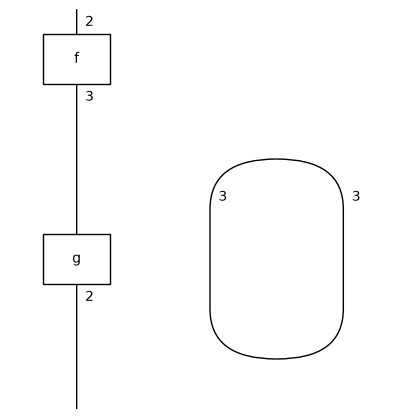

In [2]:
x, y = Dim(2), Dim(3)

# two morphisms of N; each carries one module of width dom + cod
f = Network('f', x, y, module=mlp(2 + 3))    # f : Dim(2) -> Dim(3), on R^5
g = Network('g', y, x, module=mlp(3 + 2))    # g : Dim(3) -> Dim(2), on R^5

h = f >> g                                   # composition: types compose
print(f"f >> g : {h.dom} -> {h.cod}")

# compact closure: bend g's wires around with a cap and a cup,
# turning the composite into a feedback loop on f
feedback = f @ Cap(y, y) >> g @ Id(y @ y) >> Id(x) @ Cup(y, y)
print(f"feedback : {feedback.dom} -> {feedback.cod}")
feedback.draw(figsize=(4, 4))

The compact axioms hold once diagrams are compared by their wiring rather than layer by layer, which is what `Diagram.use_hypergraph_equality = True` switches on. The defining snake equations state that bending a wire to the right and then to the left, or to the left and then to the right, has the same effect as not bending it at all. Both directions of bending correspond to the two calls to `.transpose()` used below.

In [3]:
Diagram.use_hypergraph_equality = True
assert Id(x).transpose() == Id(x) == Id(x).transpose(left=True)   # the snakes
Diagram.use_hypergraph_equality = False

### Message passing is the geometry of interaction

A diagram is evaluated by turning it into a *combinatorial map* through the method `.to_map()`, which is formally the functor `Diagram.map_factory = CMap` landing in `discopy.cmap`, the category whose morphisms are permutations on finite sets of ports.Here, the cups, caps, and swaps dissolve, leaving behind nothing but wiring in the form of a fixed-point-free involution $\sigma$ on the set of ports, stored as `edges`. Only the `Network` boxes survive, each still carrying its module $f_i$. We call the resulting map runs synchronous message passing, and one round of it is a single application of the endomorphism

$$
\Phi \;=\; \sigma \circ {\textstyle\bigoplus_i} f_i
\qquad\text{on}\qquad
{\textstyle\bigoplus_i} \, \mathbb{R}^{w_i},
$$

the vector space of all port messages taken together. Concretely, every box first reads the incoming message on each of its ports, feeds their concatenation to its module, and splits the resulting output back into one outgoing message per port; then $\sigma$ routes every outgoing message to the port lying at the other end of its wire; and finally the boundary inputs are delivered again along their wires, ready for the next round.

The call `forward(x, n_rounds=k)` iterates $\Phi$ exactly $k$ times, and this iteration is the execution formula of the geometry of interaction; see Abramsky's *Retracing some paths in process algebra* and `discopy.interaction` for the related Int construction of Joyal, Street, and Verity. Because $\Phi$ is one fixed endomorphism being iterated, rounds compose: running it for $a + b$ steps has the same effect as running it for $a$ steps and then resuming for $b$ more, since $\Phi^{a+b} = \Phi^b \circ \Phi^a$. For a map with no boxes at all, execution reduces to pure rerouting, since $\Phi$ is then equal to $\sigma$ itself:

In [4]:
snake = Id(Dim(2)).transpose().to_map()
assert snake.boxes == ()                       # the cup and cap dissolved

point = torch.tensor([[0.1, 0.2]])
assert (snake(point) == point).all()           # rerouted, unchanged

swap = Diagram.swap(Dim(2), Dim(3)).to_map()
swap(torch.tensor([[1., 2., 3., 4., 5.]]))     # blocks exchanged

tensor([[3., 4., 5., 1., 2.]])

In [5]:
# the execution formula by hand, on the smallest possible map: one box.
# f : Dim(2) -> Dim(3) has four ports: boundary input, box domain port,
# box codomain port, boundary output.
fm = f.to_map()
print(f"port widths: {fm.port_widths}")

# one round: the box reads [input, 0] (nothing has arrived on its codomain
# port yet), its module runs, and sigma routes the last 3 coordinates of the
# output to the boundary.
xin = torch.rand(1, 2)
with torch.no_grad():
    by_map = fm(xin, n_rounds=1)
    by_hand = f.module(torch.cat([xin, torch.zeros(1, 3)], -1))[:, 2:]
assert torch.allclose(by_map, by_hand)
print("one round of the map == route the module output along sigma  ✓")

port widths: (2, 2, 3, 3)
one round of the map == route the module output along sigma  ✓


## The syntactic category $S$

The category $S$ is `discopy.frobenius`, the free hypergraph category generated by the roles. A hypergraph category is a symmetric category equipped with a supply of spiders, that is, special commutative Frobenius algebras on each object. The objects of $S$ are `frobenius.Ty` types built from a small handful of atoms called *roles*, such as `Ty("peer")`, `Ty("state")`, and `Ty("clue")`. A type is simply a finite list of roles, serving as the port signature of a box, and it is self-dual just as in $N$, which is essential because a wire may need to connect two codomain ports at once, something closed maps require constantly.

The morphisms of $S$ are plain instances of `frobenius.Box(name, dom, cod)`, an empty shell carrying no module at all, whose only content is its name and its port signature. From a collection of such boxes, the constructor `CMap.from_wiring(boxes, wires)` builds a closed combinatorial map, where each wire is given as a pair of `(box, port)` endpoints, and together all the wires form a fixed-point-free involution $\sigma$ on the ports.

Two remarks: First, they have no boundary at all, meaning no global input or output; inputs will instead enter as initial messages, and outputs will be read off as per-box emissions. Second, a wire connecting two ports of the same box constitutes a *trace*, that is, a feedback loop: whatever the box emits along that wire comes back to itself on the following round. Two such idioms recur throughout this notebook, a state loop that stores private memory surviving from round to round, and a clue loop that serves as a parking slot where a problem input is written once and read repeatedly.

All of this data assembles into a typed graph in the usual graph-theoretic sense. A vertex of the graph is a box, labeled by its name, and it carries a fixed, ordered tuple of half-edges, one for every port in its signature, with every half-edge itself labeled by the role it carries. A wire is then nothing more than a pairing of two half-edges of the same role, since a wire can only ever connect ports of equal type, and the resulting edge of the graph is a self-loop exactly when its two half-edges sit on the same vertex, which is precisely a trace; it connects two distinct vertices otherwise, exactly as an ordinary graph edge would. This is the very same fixed-point-free involution $\sigma$ introduced above, read now as a graph rather than as a permutation, and it is the picture that `CMap.draw()` renders directly: boxes as labeled nodes, ports as labeled half-edges, and wires as typed edges between them.

The following example builds a tiny skeleton consisting of two cells that talk to each other over a single peer wire, each additionally carrying its own state loop.

cell : Ty() -> peer @ state @ state
boxes: ['cell', 'cell'],  ports: 6,  sigma: (1, 0, 5, 4, 3, 2)


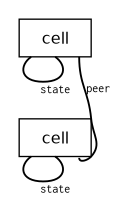

In [6]:
# the roles: atomic objects of S
PEER, STATE, CLUE = Ty("peer"), Ty("state"), Ty("clue")

# one generating morphism: a cell shell with one peer port and a state loop
cell = Box("cell", Ty(), PEER @ STATE ** 2)
print(f"cell : {cell.dom} -> {cell.cod}")

# a closed map: two cells, one peer wire, two state loops
tiny = frobenius.CMap.from_wiring(
    boxes=(cell, cell),
    wires=[((0, 0), (1, 0)),      # cell 0's peer port <-> cell 1's peer port
           ((0, 1), (0, 2)),      # cell 0's state loop  (a trace)
           ((1, 1), (1, 2))])     # cell 1's state loop  (a trace)

print(f"boxes: {[box.name for box in tiny.boxes]},  ports: {tiny.n_ports},  "
      f"sigma: {tiny.edges}")
assert all(tiny.edges[tiny.edges[i]] == i != tiny.edges[i]
           for i in range(tiny.n_ports))     # sigma is a fixpoint-free involution
tiny.draw()

### The skeleton as a string diagram

The constructor `CMap.from_wiring` is ultimately just a convenience: under the hood, a wire between two ports is nothing but a `Cup`, so wiring truly is compact closure rather than merely an analogy for it. The same skeleton can be built by hand using only `>>`, `@`, and `Cup`, closing in turn the state loop of cell 0, the state loop of cell 1, and finally the peer wire connecting the two cells, and one can check directly that this produces the very same involution $\sigma$ as before.

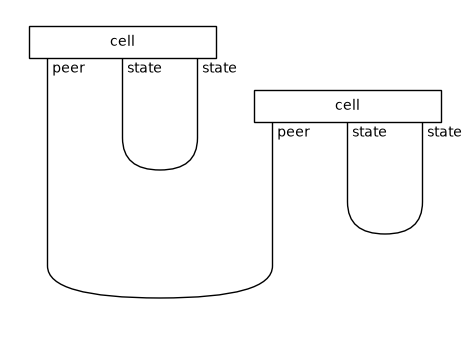

In [7]:
# tiny, rebuilt by hand with Cup instead of from_wiring -- the receipt for
# Section 2's claim that "a wire is a cup"
cell_split = Box("cell", Ty(), PEER @ STATE @ STATE)   # STATE ** 2 spelled out

skeleton_diagram = (
    cell_split @ cell_split
    >> frobenius.Id(PEER) @ frobenius.Cup(STATE, STATE)
       @ frobenius.Id(PEER @ STATE @ STATE)                     # cup cell 0's state loop
    >> frobenius.Id(PEER @ PEER) @ frobenius.Cup(STATE, STATE)  # cup cell 1's state loop
    >> frobenius.Cup(PEER, PEER)                                # cup the peer wire
)
assert skeleton_diagram.dom == skeleton_diagram.cod == Ty()      # closed: no boundary
assert skeleton_diagram.to_map().edges == tiny.edges             # same sigma as `tiny`

skeleton_diagram.draw(figsize=(4.5, 3.2))    # the string-diagram picture
#skeleton_diagram.draw(to_tikz=True)          # ... and the TikZ source that draws it

In [8]:
# three helpers to read a closed skeleton back, port by port
# (inlined from docs/neural/sudoku/skeleton.py)

def logical_ports(cmap, index):
    """Global port indices of a box in logical order: domain then codomain,
    undoing the clockwise storage order which keeps the codomain reversed."""
    start = len(cmap.dom)
    for box in cmap.boxes[:index]:
        start += len(box.dom) + len(box.cod)
    box = cmap.boxes[index]
    arity = len(box.dom)
    ports = tuple(range(start, start + arity + len(box.cod)))
    return ports[:arity] + tuple(reversed(ports[arity:]))


def wires_of(cmap):
    """The wires of a closed map as pairs of (box, port) pairs —
    the inverse of CMap.from_wiring."""
    to_logical = {port: (index, position)
                  for index in range(len(cmap.boxes))
                  for position, port in enumerate(logical_ports(cmap, index))}
    return tuple((to_logical[i], to_logical[j])
                 for i, j in enumerate(cmap.edges) if i < j)


def roles_of(cmap, index):
    """The role of each logical port of a box: its domain then its codomain."""
    box = cmap.boxes[index]
    return tuple(box.dom) + tuple(box.cod)


print(f"wires, read back:  {wires_of(tiny)}")
print(f"roles of a cell:   {[str(role) for role in roles_of(tiny, 0)]}")

wires, read back:  (((0, 2), (0, 1)), ((0, 0), (1, 0)), ((1, 2), (1, 1)))
roles of a cell:   ['peer', 'state', 'state']


### A worked example: three cells in a ring

The two-cell example above already has one edge and two self-loops, but a graph only really starts to look like a graph once it has more than one route through it. The following skeleton reuses the same two roles, `peer` and `state`, and arranges three cells in a ring: every cell now carries two peer ports instead of one, one wired to the cell before it and one to the cell after it, so the peer wires alone trace out a triangle, while each cell keeps its own state loop exactly as before. The helper functions defined above make no assumption, so they apply to this new skeleton unchanged, printing out its vertices, the type of every half-edge, and the matching between them.

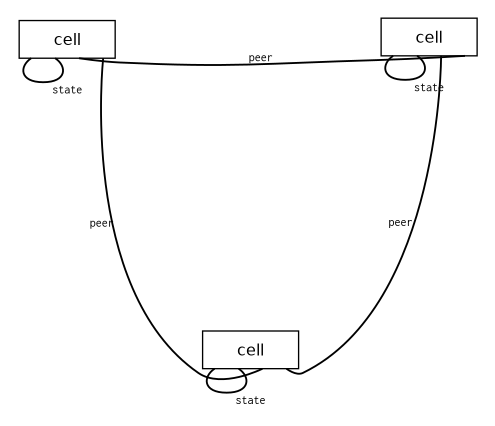

vertices:        ['cell', 'cell', 'cell']
half-edge types: ['peer', 'peer', 'state', 'state'] (cell 0)
matching:
  cell0.3 <-> cell0.2
  cell0.1 <-> cell1.0
  cell0.0 <-> cell2.1
  cell1.3 <-> cell1.2
  cell1.1 <-> cell2.0
  cell2.3 <-> cell2.2


In [9]:
# a richer example: three cells in a ring, using the same two roles as tiny
ring_cell = Box("cell", Ty(), PEER ** 2 @ STATE ** 2)

ring = frobenius.CMap.from_wiring(
    boxes=(ring_cell, ring_cell, ring_cell),
    wires=[((0, 1), (1, 0)),      # cell 0 to cell 1
           ((1, 1), (2, 0)),      # cell 1 to cell 2
           ((2, 1), (0, 0)),      # cell 2 to cell 0, closing the ring
           ((0, 2), (0, 3)), ((1, 2), (1, 3)), ((2, 2), (2, 3))])  # state loops

assert all(ring.edges[ring.edges[i]] == i != ring.edges[i]
           for i in range(ring.n_ports))     # still a fixpoint-free involution
ring.draw(engine="neato")   # boxes as nodes, ports as half-edges, wires as typed edges

print("vertices:       ", [box.name for box in ring.boxes])
print("half-edge types:", [str(role) for role in roles_of(ring, 0)], "(cell 0)")
print("matching:")
for one, other in wires_of(ring):
    print(f"  cell{one[0]}.{one[1]} <-> cell{other[0]}.{other[1]}")

## The functor $F : S \to N$

Now that we have defined both $S$ and $N$, we have to describe how the functor $F$ that goes from the first to the second looks like. Formally, $F$ is an instance of `discopy.neural.Functor`, an ordinary monoidal functor such that $F(u \otimes v) = F(u) \otimes F(v)$, and  `F(f >> g) == F(f) >> F(g)`. Concretely, `ob` sends each atomic role to the `Dim` it will carry, while `ar` sends each abstract box to a `Network` of the corresponding image type, $F(\mathtt{cell}) : F(\mathrm{dom}) \to F(\mathrm{cod})$, carrying the actual torch module that will do the computing.

The wiring of a skeleton, however, does not rely on any of this generic machinery, since it is not itself a composite built from `>>` and `@` but rather the extra combinatorial data attached to a closed map. For this reason, the function `interpret` defined below does not ask $F$ to open up an entire diagram at once; instead it applies $F$ port by port, sending each box to its image `Network` and each wire to a wire between the corresponding image ports. This is the boundary between syntax and semantics: the skeleton fixes the combinatorics, while the functor fixes the widths and the modules.

One feature of this construction deserves particular emphasis. Since `Dim(0)` is the monoidal unit of $N$, sending a role to `Dim(0)` means that this role carries nothing at all, and a port that carries nothing is not there at all either: `interpret` erases it, together with any wire whose two endpoints have both been erased. A single skeleton can therefore serve several different architectures at once, since keeping or erasing a state loop, keeping or erasing an answer loop, and so on, are all decided purely through the object map. A wire may only be erased as a whole, though: erasing exactly one of its two endpoints is a type error, and `interpret` raises an exception in that case.

In [10]:
# (inlined, lightly simplified, from docs/neural/core/functors.py)

def make_functor(ob, modules, abstract):
    """The neural functor with object map `ob`, sending each abstract box of
    `abstract` to a Network of the image type around modules[box.name].
    Note that one shared module means one shared box: weights are tied."""
    types = Functor(ob=ob, dom=frobenius.Diagram)          # F on objects only
    networks = {box: Network(box.name, types(box.dom), types(box.cod),
                             module=modules[box.name])
                for box in dict.fromkeys(abstract.boxes)}
    return Functor(ob=ob, ar=networks, dom=frobenius.Diagram)


def interpret(functor, abstract):
    """Apply a neural functor to a closed skeleton, port by port."""
    boxes = tuple(functor(box) for box in abstract.boxes)
    for box, image in zip(abstract.boxes, boxes):
        assert isinstance(image, Network)
        assert (image.dom, image.cod) == (functor(box.dom), functor(box.cod))

    # where each abstract port lands, and whether it was erased by Dim(0)
    erased, position = {}, {}
    for index in range(len(abstract.boxes)):
        cursor = 0
        for pos, role in enumerate(roles_of(abstract, index)):
            width = functor(role)
            assert len(width) <= 1, f"{role} maps to the non-atomic {width}"
            erased[index, pos] = not len(width)      # Dim(0) has length 0
            position[index, pos] = cursor
            cursor += len(width)

    # each wire becomes a wire between image ports, or vanishes whole
    wires = []
    for one, other in wires_of(abstract):
        if erased[one] and erased[other]:
            continue
        assert not (erased[one] or erased[other]), \
            f"the wire {one} -- {other} is only erased at one end"
        wires.append(((one[0], position[one]), (other[0], position[other])))
    return CMap.from_wiring(boxes, wires)

In [11]:
# --- functor 1: a "wide" interpretation ------------------------------------
ob_wide = {PEER: Dim(2), STATE: Dim(3)}
F_wide = make_functor(ob_wide, {"cell": mlp(2 + 3 + 3)}, tiny)

print("F_wide on objects:")
for role, dim in ob_wide.items():
    print(f"    F({role}) = {dim}")
image = F_wide(cell)
print(f"F_wide on morphisms:\n    F(cell) = {image!r},")
print(f"        carrying one {type(image.module).__name__} on "
      f"R^{sum(image.cod.inside)}")
assert F_wide(PEER @ STATE ** 2) == F_wide(PEER) @ F_wide(STATE) ** 2

wide = interpret(F_wide, tiny)
out = wide(n_rounds=3)         # a closed map returns the per-box emissions
print(f"image map: port widths {wide.port_widths};  3 rounds of message "
      f"passing -> {len(out)} tensors of shape {tuple(out[0].shape)}")

# --- functor 2: the same skeleton, with the state loops erased -------------
F_erased = make_functor({PEER: Dim(2), STATE: Dim(0)}, {"cell": mlp(2)}, tiny)
erased = interpret(F_erased, tiny)
print(f"\nF(STATE) = Dim(0):  port widths {erased.port_widths}  "
      "(the state loops vanished)")

# --- functor 3: same widths as F_wide, a different module — plug and play --
F_swapped = make_functor(ob_wide, {"cell": torch.nn.Linear(8, 8)}, tiny)
swapped = interpret(F_swapped, tiny)
assert swapped.port_widths == wide.port_widths
print(f"\nsame skeleton, same widths, module swapped: "
      f"{type(swapped.boxes[0].module).__name__} instead of "
      f"{type(wide.boxes[0].module).__name__}")

F_wide on objects:
    F(peer) = Dim(2)
    F(state) = Dim(3)
F_wide on morphisms:
    F(cell) = neural.Network('cell', dom=Dim(0), cod=Dim(2, 3, 3)),
        carrying one Sequential on R^8
image map: port widths (3, 3, 2, 3, 3, 2);  3 rounds of message passing -> 2 tensors of shape (1, 8)

F(STATE) = Dim(0):  port widths (2, 2)  (the state loops vanished)

same skeleton, same widths, module swapped: Linear instead of Sequential


## Solving 6×6 sudoku

A 6×6 sudoku fills a grid of six rows, six columns, and six $2 \times 3$ blocks with the digits 1 through 6, so that every row, every column, and every block contains each digit exactly once. Equivalently, no two peers, meaning two cells sharing a row, a column, or a block, may hold the same digit, and every cell has exactly 12 such peers.

In [13]:
# puzzle machinery: generation by backtracking, checking, decoding
# (as in neural-sudoku.ipynb, generalised to any block shape)

def solve_sudoku(grid, block=(2, 3), digits=None):
    """Solve a grid by backtracking, with 0 for blanks."""
    peers = sudoku_peers(block)
    size = block[0] * block[1]
    digits = tuple(range(1, size + 1)) if digits is None else digits
    grid = list(grid)

    def fill(cell):
        if cell == size * size:
            return True
        if grid[cell]:
            return all(grid[p] != grid[cell] for p in peers[cell]) \
                and fill(cell + 1)
        for digit in digits:
            if all(grid[p] != digit for p in peers[cell]):
                grid[cell] = digit
                if fill(cell + 1):
                    return True
        grid[cell] = 0
        return False

    return tuple(grid) if fill(0) else None


def random_sudoku(block=(2, 3), n_clues=14, seed=0):
    """A random puzzle and its solution: solve a blank grid, blank cells."""
    size = block[0] * block[1]
    generator = random.Random(seed)
    digits = list(range(1, size + 1))
    generator.shuffle(digits)
    solution = solve_sudoku(size * size * (0, ), block, tuple(digits))
    cells = list(range(size * size))
    generator.shuffle(cells)
    clues = list(solution)
    for cell in cells[:size * size - n_clues]:
        clues[cell] = 0
    return tuple(clues), solution


def check_sudoku(grid, block=(2, 3)):
    """Whether a completed grid satisfies all the constraints."""
    peers = sudoku_peers(block)
    size = block[0] * block[1]
    return all(d in range(1, size + 1) for d in grid) and all(
        grid[cell] != grid[peer]
        for cell in range(size * size) for peer in peers[cell])


def decode_sudoku(logits, clues):
    """Keep the clues, take the most likely digit for each blank cell."""
    result = []
    for cell, clue in enumerate(clues):
        if clue:
            result.append(clue)
        else:
            row = list(logits[cell])
            result.append(1 + max(range(len(row)), key=row.__getitem__))
    return tuple(result)


def sudoku_peers(block=(2, 3)):
    """Peers of each cell: same row, same column or same h x w block."""
    height, width = block
    size = height * width

    def same_unit(cell, other):
        (r, c), (rr, cc) = divmod(cell, size), divmod(other, size)
        return r == rr or c == cc or \
            (r // height, c // width) == (rr // height, cc // width)

    return tuple(tuple(sorted(
        other for other in range(size * size)
        if other != cell and same_unit(cell, other)))
        for cell in range(size * size))


def show(grid):
    size = int(len(grid) ** 0.5)
    return "\n".join(
        " ".join(str(digit) if digit else "."
                 for digit in grid[row:row + size])
        for row in range(0, size * size, size))


# 14 of 36 cells given: hard enough that the training set cannot be
# memorised into a solver, and ambiguous enough that some puzzles have
# several valid completions
puzzles = [random_sudoku(block=(2, 3), n_clues=14, seed=seed)
           for seed in range(320)]
train_set, test_set = puzzles[:256], puzzles[256:]

train_clues = torch.tensor([clue for clue, _ in train_set], device=device)
train_targets = torch.tensor(
    [solution for _, solution in train_set], device=device) - 1
test_clues = torch.tensor([clue for clue, _ in test_set], device=device)

print(show(train_set[0][0]), "\n\n" + show(train_set[0][1]))

. . . 1 6 .
. . 4 5 . .
. 5 . . 4 6
. 4 . . 5 .
6 2 . . . 3
4 . . . 2 . 

5 3 2 1 6 4
1 6 4 5 3 2
3 5 1 2 4 6
2 4 6 3 5 1
6 2 5 4 1 3
4 1 3 6 2 5


### The first topology: a clique of peers

The first topology wires every cell to each of its 12 peers, together with a private state loop and a clue loop, giving every cell the signature $\mathtt{peer}^{12} \otimes \mathtt{state}^2 \otimes \mathtt{clue}^2$; we call this the clique. We interpret this one skeleton with two functors that differ only in their object map, giving two architectures for the cell module:

| | feedforward | recurrent |
|---|---|---|
| `PEER` | `Dim(dim)` | `Dim(dim)` |
| `STATE` | `Dim(0)`, erased | `Dim(state_dim)` |
| `CLUE` | `Dim(0)`, erased | `Dim(dim)` |

The feedforward functor erases both loops, so its cells carry no memory between rounds and the clues must be re-injected on the peer ports at every round; each cell is realized as a plain multilayer perceptron, a fixed-width module tied to exactly 12 peer ports. The recurrent functor keeps both loops instead: the state loop becomes the hidden state of a gated recurrent unit, and the clue loop becomes the slot in which the puzzle itself is written.

A gated recurrent unit, or GRU, updates its hidden state by blending it with a freshly computed candidate rather than simply overwriting it: a learned gate decides, coordinate by coordinate, how much of the old state to keep and how much new information to fold in. This suits constraint propagation well, since a cell should accumulate confidence gradually over many rounds of message passing rather than reset its belief at every step, and the same gating keeps gradients well behaved across so many unrolled rounds, unlike a plain recurrent cell. Concretely, the module below pools the incoming peer messages by averaging, which keeps it equivariant to the order in which peers happen to be listed, concatenates the result with the clue, and feeds both to a `torch.nn.GRUCell` alongside the previous state; because it reads the number of peers directly off its input width rather than hard-coding it, the same weights are not tied to any particular peer count.

In [14]:
def sudoku_skeleton(block=(2, 3)):
    """One shared cell shell per cell, with the full signature
    PEER^P @ STATE^2 @ CLUE^2; a wire between each pair of peers, plus a
    state loop and a clue loop on every cell.  Pure syntax: no widths,
    no modules, no torch."""
    peers = sudoku_peers(block)
    n_cells, P = len(peers), len(peers[0])
    shell = Box("cell", Ty(), PEER ** P @ STATE ** 2 @ CLUE ** 2)
    wires = [((c, peers[c].index(o)), (o, peers[o].index(c)))
             for c in range(n_cells) for o in peers[c] if c < o]
    for c in range(n_cells):
        wires.append(((c, P), (c, P + 1)))          # state loop
        wires.append(((c, P + 2), (c, P + 3)))      # clue loop
    return frobenius.CMap.from_wiring(n_cells * (shell, ), wires)


skeleton6 = sudoku_skeleton(block=(2, 3))
P6 = len(sudoku_peers(block=(2, 3))[0])
print(f"6x6 skeleton: {len(skeleton6.boxes)} cells, {P6} peers per cell, "
      f"{skeleton6.n_ports // 2} wires")

6x6 skeleton: 36 cells, 12 peers per cell, 288 wires


In [15]:
def gru_cell(dim, state_dim, hidden_dim=None):
    """The module behind the recurrent functor.

    It reads its ports in the cell's logical order ``[m_1 .. m_P | h, h' |
    c, c']``: P peer messages, the state loop pair, the clue loop pair.
    Each round it encodes every peer message against its own state,
    mean-pools the encodings, runs a GRU update from the pool and the clue,
    then broadcasts a fresh belief to its peers and emits the new state on
    both state ports.  On the clue ports it emits zeros, so the injected
    clue arrives unchanged every round.

    The number of peers is read off the input width, so the same weights
    run on any grid size."""
    hidden_dim = hidden_dim or 2 * state_dim

    class EquivariantGRUCell(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.dim, self.state_dim = dim, state_dim
            self.encode = torch.nn.Sequential(
                torch.nn.Linear(state_dim + dim, hidden_dim),
                torch.nn.ReLU(), torch.nn.Linear(hidden_dim, hidden_dim))
            self.update = torch.nn.GRUCell(hidden_dim + dim, state_dim)
            self.norm = torch.nn.LayerNorm(state_dim)
            self.emit = torch.nn.Linear(state_dim, dim)

        def forward(self, x):
            d, s = self.dim, self.state_dim
            P = (x.shape[-1] - 2 * s - 2 * d) // d
            peers = x[:, :P * d].reshape(-1, P, d)
            state = x[:, P * d:P * d + s]
            clue = x[:, P * d + 2 * s:P * d + 2 * s + d]
            pooled = self.encode(torch.cat([
                state.unsqueeze(1).expand(-1, P, -1), peers], -1)).mean(1)
            state = self.norm(self.update(
                torch.cat([pooled, clue], -1), state))
            return torch.cat([
                self.emit(state).unsqueeze(1).expand(-1, P, -1)
                    .reshape(-1, P * d),
                state, state,
                torch.zeros_like(clue), torch.zeros_like(clue)], -1)

    return EquivariantGRUCell()

In [16]:
dim, state_dim = 8, 16

F_feedforward6 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(0), CLUE: Dim(0)},
    modules={"cell": mlp(P6 * dim)}, abstract=skeleton6)
rec_module = gru_cell(dim, state_dim)
F_recurrent6 = make_functor(
    ob={PEER: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": rec_module}, abstract=skeleton6)

grid6_ff = interpret(F_feedforward6, skeleton6)
grid6_rec = interpret(F_recurrent6, skeleton6)

for name, grid in [("feedforward", grid6_ff), ("recurrent", grid6_rec)]:
    widths = grid.port_widths
    n_parameters = sum(p.numel() for p in grid.parameters())
    print(f"{name:12s} image: {len(grid.boxes)} cells x "
          f"{len(widths) // len(grid.boxes)} ports, {len(widths) // 2} wires, "
          f"{n_parameters} shared parameters")

assert grid6_ff.port_widths == 36 * P6 * (dim, )     # the loops are erased
assert len(grid6_rec.port_widths) == 36 * (P6 + 4)   # P6 peers + 2 + 2 loops

# the two spellings of execution agree: the vectorized flat-tensor pass
# and the readable one-call-per-box reference
init = torch.rand(4, sum(grid6_rec.port_widths))
with torch.no_grad():
    reference = grid6_rec.forward_reference(init=init, n_rounds=3)
    vectorized = grid6_rec.forward(init=init, n_rounds=3)
assert all(torch.allclose(a, b, atol=1e-5)
           for a, b in zip(reference, vectorized))
print("forward == forward_reference  ✓")

feedforward  image: 36 cells x 12 ports, 216 wires, 37152 shared parameters
recurrent    image: 36 cells x 16 ports, 288 wires, 4808 shared parameters
forward == forward_reference  ✓


### The second topology: a factor graph

The clique is not the only way to wire the constraints together, and this is the whole point of keeping the syntax separate from the semantics: for a single problem, several different topologies can be tried. As we said, a 6x6 sudoku constraint states that some six cells must hold six distinct digits, encoded by the  clique as $\binom{6}{2} = 15$ pairwise wires per constraint. The factor graph instead encodes it as a single relation box: a new generating shell we call *unit* for each row, column, and block. This shell carries a message port per member, together with a cell shell cut down to just three message ports, one toward its row, one toward its column, and one toward its block, plus the same state and clue loops as before. This amounts to $36 + 18 = 54$ boxes, compared with the clique's 36, and $108 + 72 = 180$ wires, consisting of $36 \times 3$ cell-to-unit wires plus the 72 loop wires, compared with the clique's $216 + 72 = 288$, made up of its 216 peer wires plus the same 72 loop wires. The factor graph is, in other words, a considerably sparser map, bought at the cost of one additional box shape.

On the semantic side, the functor needs exactly one new module, a Deep-Sets relation for the `unit` box that pools its members into an order-invariant summary and answers each member in turn, while the `cell` box simply reuses the very same `gru_cell` class as before: since it reads its port count directly from the width, it now reads three unit summaries instead of twelve raw peer messages, with no change to its implementation. The price paid for this sparsity is graph-distance: a belief now travels from cell to unit to cell, so a single cell-to-cell hop costs two rounds here rather than the one round it costs in the clique. This map is accordingly given 24 rounds, amounting to 12 hops, against the clique's 16.

In [17]:
MESSAGE = Ty("message")     # a fourth role: a cell-to-unit wire


def sudoku_units(block=(2, 3)):
    """The row, column and block unit index of each cell."""
    height, width = block
    size = height * width
    units = []
    for cell_index in range(size * size):
        row, column = divmod(cell_index, size)
        block_index = (row // height) * (size // width) + (column // width)
        units.append((row, size + column, 2 * size + block_index))
    return tuple(units)


def factor_skeleton(block=(2, 3)):
    """The bipartite factor graph: one cell shell with three MESSAGE ports
    and the two loops, one unit shell per row/column/block with one MESSAGE
    port per member, and a wire from each cell to each of its three units.
    Pure syntax again — the same move as sudoku_skeleton, different wiring."""
    height, width = block
    size = height * width
    n_cells = size * size
    units = sudoku_units(block)
    cell_shell = Box("cell", Ty(), MESSAGE ** 3 @ STATE ** 2 @ CLUE ** 2)
    unit_shell = Box("unit", Ty(), MESSAGE ** size)
    free = [0] * (3 * size)
    wires = []
    for index in range(n_cells):
        for position, unit_index in enumerate(units[index]):
            wires.append(
                ((index, position), (n_cells + unit_index, free[unit_index])))
            free[unit_index] += 1
        wires.append(((index, 3), (index, 4)))      # state loop
        wires.append(((index, 5), (index, 6)))      # clue loop
    assert all(slot == size for slot in free), "a unit box is not full"
    return frobenius.CMap.from_wiring(
        (cell_shell, ) * n_cells + (unit_shell, ) * (3 * size), wires)


class FactorBox(torch.nn.Module):
    """A permutation-equivariant Deep-Sets relation over one unit's
    members: pool an order-invariant summary of the unit (a sum), answer
    each member with that summary alongside its own message."""
    def __init__(self, dim, hidden):
        super().__init__()
        self.dim = dim
        self.phi = torch.nn.Sequential(
            torch.nn.Linear(dim, hidden), torch.nn.ReLU())
        self.rho = torch.nn.Sequential(
            torch.nn.Linear(dim + hidden, hidden), torch.nn.ReLU(),
            torch.nn.Linear(hidden, dim))

    def forward(self, x):
        members = x.shape[-1] // self.dim
        message = x.reshape(-1, members, self.dim)
        pooled = self.phi(message).sum(1, keepdim=True).expand(
            -1, members, -1)
        return self.rho(torch.cat([message, pooled], -1)).reshape(
            -1, members * self.dim)


skeleton6_factor = factor_skeleton(block=(2, 3))
F_factor6 = make_functor(
    ob={MESSAGE: Dim(dim), STATE: Dim(state_dim), CLUE: Dim(dim)},
    modules={"cell": gru_cell(dim, state_dim),   # same class, fresh weights
             "unit": FactorBox(dim, 32)},
    abstract=skeleton6_factor)
grid6_fac = interpret(F_factor6, skeleton6_factor)

print(f"{'topology':16s}{'boxes':>6s}{'wires':>7s}{'parameters':>12s}")
for name, grid in [("ff clique", grid6_ff), ("rec clique", grid6_rec),
                   ("rec factor", grid6_fac)]:
    print(f"{name:16s}{len(grid.boxes):6d}{grid.n_ports // 2:7d}"
          f"{sum(p.numel() for p in grid.parameters()):12d}")

topology         boxes  wires  parameters
ff clique           36    216       37152
rec clique          36    288        4808
rec factor          54    180        6672


### Clues in, digits out: the solvers

Since a closed map has no boundary, a solver can only talk to it through the two channels that execution provides, as described in Section 1.1. Inputs enter as initial messages: calling `forward(init=..., inject=True)` writes a tensor onto chosen ports before the first round and adds it again after every subsequent round, so that the clues behave as a persistent source throughout the computation. Outputs, meanwhile, are read off as the per-box emissions, meaning whatever each cell said on its ports after the final round.

The three interpretations built so far give rise to three different data paths, summarized below.

| | feedforward · clique | recurrent · clique | recurrent · factor |
|---|---|---|---|
| clues enter on | all 12 peer ports | the 2 clue-loop ports | the 2 clue-loop ports |
| memory | none, loops erased | the state loop, a trace | the state loop, a trace |
| read out from | the 12 emitted messages | the state slice | the state slice |
| rounds | 8 | 16 | 24, 12 hops |

It is worth noting that the two recurrent solvers are in fact a single class: the only numbers it needs, namely how many message ports a cell has and where its state slice begins, are passed in as arguments, and the cell boxes come first in both wirings by construction.

One further piece of the category is at work here. The method `grid.as_network()` wraps an already-executed map back into a `Network`, that is, a morphism of $N$ once again, which can then be used as an ordinary box inside a larger diagram. Its fresh module is kept so that torch registers the shared cell modules as submodules of the solver, which is what allows `optimizer = Adam(solver.parameters())` to see them.

In [18]:
class FeedforwardSolver(torch.nn.Module):
    """The feedforward interpretation, wrapped for training."""
    def __init__(self, grid, n_peers, size, dim=8, n_rounds=8):
        super().__init__()
        self.grid, self.n_rounds = grid, n_rounds
        self.cells = grid.as_network().module      # registers the shared module
        self.embedding = torch.nn.Embedding(size + 1, dim)  # 0 means blank
        self.readout = torch.nn.Linear(n_peers * dim, size)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell_index in range(clues.shape[1]):
            for port in self.grid.box_ports(cell_index):   # all P peer ports
                init[port] = embedded[:, cell_index, :]
        emitted = self.cells(init=init, n_rounds=self.n_rounds)
        return self.readout(torch.stack(emitted, dim=1))


class RecurrentSolver(torch.nn.Module):
    """A recurrent interpretation, wrapped for training.  Serves both the
    clique (n_message=12 peer ports) and the factor graph (n_message=3 unit
    ports): cell boxes come first in both wirings, so the clue ports and the
    state slice are found the same way."""
    def __init__(self, grid, n_message, size, dim=8, state_dim=16,
                 n_rounds=16):
        super().__init__()
        self.grid, self.n_rounds = grid, n_rounds
        self.n_message, self.dim, self.state_dim = n_message, dim, state_dim
        self.cells = grid.as_network().module
        self.embedding = torch.nn.Embedding(size + 1, dim)
        self.readout = torch.nn.Linear(state_dim, size)

    def forward(self, clues):
        embedded = self.embedding(clues)
        init = [None] * self.grid.n_ports
        for cell_index in range(clues.shape[1]):
            for port in self.grid.box_ports(cell_index)[-2:]:  # the clue pair
                init[port] = embedded[:, cell_index, :]
        emitted = self.cells(init=init, n_rounds=self.n_rounds)
        offset = self.n_message * self.dim       # the state slice of a cell
        states = torch.stack(
            [emitted[cell][:, offset:offset + self.state_dim]
             for cell in range(clues.shape[1])], dim=1)   # cell boxes first
        return self.readout(states)

In [20]:
SIZE = 6

def accuracy(model):
    """Cell agreement with the recorded solution, and the fraction of
    boards completed *validly*, on the held-out set."""
    model.eval()
    with torch.no_grad():
        logits = model(test_clues).cpu()
    decoded = [decode_sudoku(logits[i], test_set[i][0])
               for i in range(len(test_set))]
    cell_accuracy = sum(
        digit == expected
        for grid, (_, solution) in zip(decoded, test_set)
        for digit, expected in zip(grid, solution)) \
        / (SIZE * SIZE * len(test_set))
    valid = sum(check_sudoku(grid) for grid in decoded) / len(test_set)
    return cell_accuracy, valid


def fit(model, n_steps, lr, eval_every=25, batch_size=32):
    """Train, recording the loss at every step and the held-out accuracy
    every `eval_every` steps (evaluation time excluded from the clock)."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "eval_step": [], "seconds": [],
               "cell": [], "valid": []}
    start, spent_evaluating = time.perf_counter(), 0.0
    for step in range(1, n_steps + 1):
        model.train()
        batch = torch.randint(0, len(train_clues), (batch_size, ),
                              device=device)
        optimizer.zero_grad()
        logits = model(train_clues[batch])
        loss = torch.nn.functional.cross_entropy(
            logits.reshape(-1, SIZE), train_targets[batch].reshape(-1))
        loss.backward()
        optimizer.step()
        history["loss"].append(loss.item())
        if step % eval_every == 0 or step == n_steps:
            tick = time.perf_counter()
            history["seconds"].append(tick - start - spent_evaluating)
            cell_accuracy, valid = accuracy(model)
            history["eval_step"].append(step)
            history["cell"].append(cell_accuracy)
            history["valid"].append(valid)
            spent_evaluating += time.perf_counter() - tick
    return history

In [21]:
feedforward = FeedforwardSolver(grid6_ff, n_peers=P6, size=SIZE)
recurrent = RecurrentSolver(grid6_rec, n_message=P6, size=SIZE)
factor = RecurrentSolver(grid6_fac, n_message=3, size=SIZE, n_rounds=24)
solvers = [("ff clique", feedforward), ("rec clique", recurrent),
           ("rec factor", factor)]
for name, model in solvers:
    print(f"{name:12s}: {sum(p.numel() for p in model.parameters()):6d} "
          "parameters")

history_ff = fit(feedforward, n_steps=800, lr=3e-3)
history_rec = fit(recurrent, n_steps=800, lr=5e-3)
history_fac = fit(factor, n_steps=800, lr=5e-3)

for name, history in [("ff clique", history_ff), ("rec clique", history_rec),
                      ("rec factor", history_fac)]:
    print(f"{name:12s}: cell accuracy {history['cell'][-1]:.0%}, "
          f"valid boards {history['valid'][-1]:.0%}  "
          f"({history['seconds'][-1]:.0f}s of training)")

ff clique   :  37790 parameters
rec clique  :   4966 parameters
rec factor  :   6830 parameters
ff clique   : cell accuracy 89%, valid boards 2%  (18s of training)
rec clique  : cell accuracy 87%, valid boards 53%  (27s of training)
rec factor  : cell accuracy 86%, valid boards 22%  (42s of training)


## Three training runs, two curves

Since only 14 of the 36 cells are given, some puzzles admit several valid completions, and this means the two metrics used to evaluate the models tell rather different stories. Cell accuracy, meaning agreement with the one recorded solution, systematically undercounts a model that has found some other, equally valid completion, so the fraction of valid boards is the honest headline number to watch.

The training curves tell a fairly consistent story: The feedforward clique drives its training loss down to essentially zero: with  ~37.000 parameters it has more than enough capacity to memorize all 256 training puzzles, yet it completes only a small fraction of held-out boards validly. Memoryless message passing has to fit the entire solving process into a single reactive map, and what it ends up learning behaves more like a lookup table than like genuine constraint propagation. The recurrent cliques, by contrast, never quite reaches zero training loss, partly because of the irreducible ambiguity just mentioned, but they generalize far better. The recurrent factor graph lands close to the clique in both cell accuracy and the fraction of valid boards, despite being the sparsest of the three maps. At the scale and budget of the 9×9 study the factor graph decisively beats the clique. 

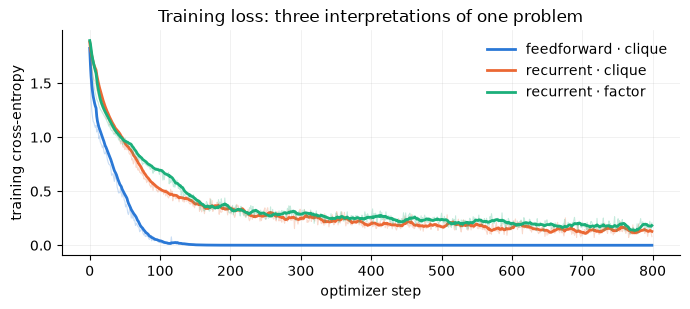

In [22]:
# colourblind-safe categorical triple, in fixed slot order
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RUNS = [(history_ff, BLUE, "feedforward · clique"),
        (history_rec, ORANGE, "recurrent · clique"),
        (history_fac, AQUA, "recurrent · factor")]


def smooth(values, window=10):
    """Rolling mean, same length as the input."""
    cumulative = [0.0]
    for value in values:
        cumulative.append(cumulative[-1] + value)
    return [(cumulative[i + 1] - cumulative[max(0, i + 1 - window)])
            / min(i + 1, window) for i in range(len(values))]


fig, ax = plt.subplots(figsize=(7, 3.2))
for history, colour, label in RUNS:
    ax.plot(history["loss"], color=colour, alpha=0.25, linewidth=0.8)
    ax.plot(smooth(history["loss"]), color=colour, linewidth=2, label=label)
ax.set_xlabel("optimizer step")
ax.set_ylabel("training cross-entropy")
ax.set_title("Training loss: three interpretations of one problem")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

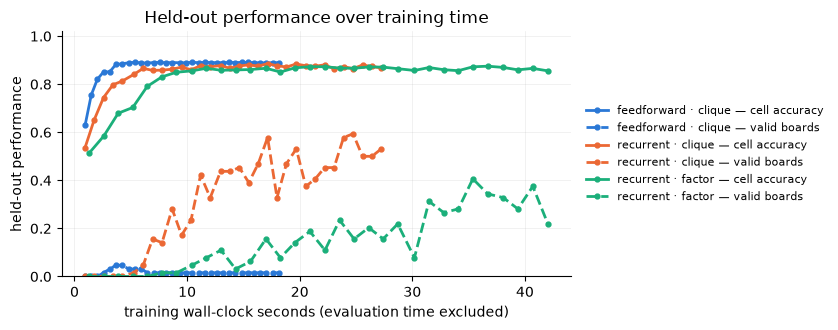

In [23]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for history, colour, label in RUNS:
    ax.plot(history["seconds"], history["cell"], color=colour, linewidth=2,
            marker="o", markersize=3.5, label=f"{label} — cell accuracy")
    ax.plot(history["seconds"], history["valid"], color=colour, linewidth=2,
            linestyle="--", marker="o", markersize=3.5,
            label=f"{label} — valid boards")
ax.set_xlabel("training wall-clock seconds (evaluation time excluded)")
ax.set_ylabel("held-out performance")
ax.set_ylim(0, 1.02)
ax.set_title("Held-out performance over training time")
ax.grid(alpha=0.25, linewidth=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="center left",
          bbox_to_anchor=(1.01, 0.5))
plt.tight_layout()
plt.show()